In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [4]:
df = pd.read_csv(r"C:\Users\HP\DATA_SCIENCE\Projects\Credit Risk Scoring\Data\credit_risk_processed.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_to_income_ratio,income_band,age_group,high_interest_flag,high_loan_burden
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3,0.593220,Medium,Young,1,1
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,0.104167,Low,Young,0,0
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,0.572917,Low,Young,0,1
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,0.534351,Medium,Young,1,1
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,0.643382,Medium,Young,0,1


In [5]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

In [6]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

numeric_features, categorical_features

(['person_age',
  'person_income',
  'person_emp_length',
  'loan_amnt',
  'loan_int_rate',
  'loan_percent_income',
  'cb_person_cred_hist_length',
  'loan_to_income_ratio',
  'high_interest_flag',
  'high_loan_burden'],
 ['person_home_ownership',
  'loan_intent',
  'loan_grade',
  'cb_person_default_on_file',
  'income_band',
  'age_group'])

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [9]:
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=y_train.value_counts()[0] / y_train.value_counts()[1],
        eval_metric="logloss",
        random_state=42
    )
}

In [10]:
results = []

trained_pipelines = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })
    
    trained_pipelines[name] = pipe

In [11]:
results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,XGBoost,0.910471,0.802850,0.786047,0.794360,0.945889
1,Random Forest,0.929400,0.965957,0.703876,0.814350,0.929701
0,Logistic Regression,0.842258,0.608696,0.792248,0.688447,0.890268


In [ ]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_pipelines[best_model_name]


best_model_name

'XGBoost'

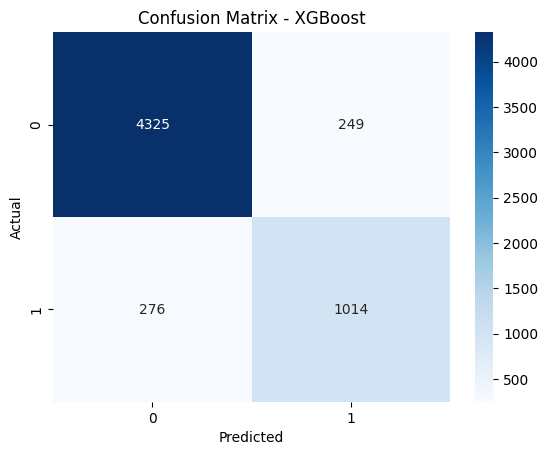

In [13]:
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.95      0.94      4574
           1       0.80      0.79      0.79      1290

    accuracy                           0.91      5864
   macro avg       0.87      0.87      0.87      5864
weighted avg       0.91      0.91      0.91      5864



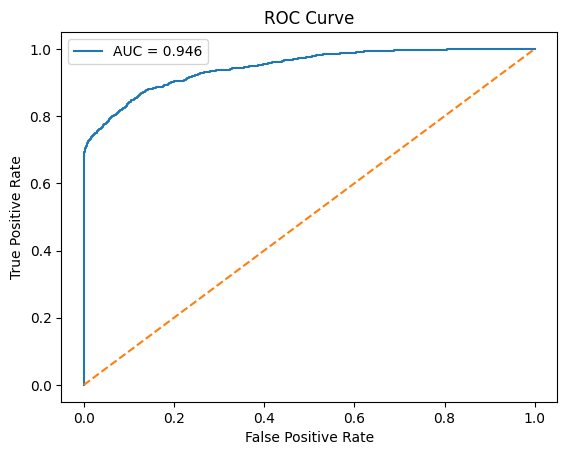

In [15]:
y_prob = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
thresholds = np.arange(0.1, 0.9, 0.01)

threshold_results = []


for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred_threshold),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1 Score": f1_score(y_test, y_pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df.sort_values(by="F1 Score", ascending=False).head()

,Threshold,Precision,Recall,F1 Score
61,0.71,0.955943,0.723256,0.823477
58,0.68,0.943888,0.730233,0.823427
60,0.70,0.953109,0.724806,0.823426
59,0.69,0.947528,0.727907,0.823323
62,0.72,0.959711,0.720155,0.822852


In [17]:
best_threshold = threshold_df.sort_values(by="F1 Score", ascending=False).iloc[0]["Threshold"]
best_threshold

0.7099999999999996

In [18]:
y_pred_tuned = (y_prob >= best_threshold).astype(int)

print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      4574
           1       0.96      0.72      0.82      1290

    accuracy                           0.93      5864
   macro avg       0.94      0.86      0.89      5864
weighted avg       0.93      0.93      0.93      5864



In [19]:
def calculate_risk_score(default_probability):
    score = int(850 - default_probability * 550)
    return max(300, min(score, 850))


def get_risk_category(score):
    if score >= 750:
        return "Low Risk"
    elif score >= 600:
        return "Medium Risk"
    else:
        return "High Risk"

In [20]:
sample_prob = y_prob[0]

risk_score = calculate_risk_score(sample_prob)
risk_category = get_risk_category(risk_score)

sample_prob, risk_score, risk_category

(0.10266629, 793, 'Low Risk')

In [21]:
def generate_reason_codes(row):
    reasons = []

    if row["loan_percent_income"] > 0.30:
        reasons.append("High loan burden compared to income")

    if row["loan_int_rate"] > 15:
        reasons.append("High interest rate")

    if row["cb_person_default_on_file"] == "Y":
        reasons.append("Historical default found")

    if row["person_income"] < 30000:
        reasons.append("Low income band")

    if row["loan_grade"] in ["D", "E", "F", "G"]:
        reasons.append("Low loan grade")

    if len(reasons) == 0:
        reasons.append("Stable borrower profile")

    return reasons

In [22]:
sample = X_test.iloc[0]
generate_reason_codes(sample)

['Stable borrower profile']

In [24]:
joblib.dump(best_model, "../models/credit_risk_model.pkl")
joblib.dump(best_threshold, "../models/best_threshold.pkl")

['../models/best_threshold.pkl']

In [25]:
! pip install shap


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


 98%|===================| 5751/5864 [00:46<00:00]        

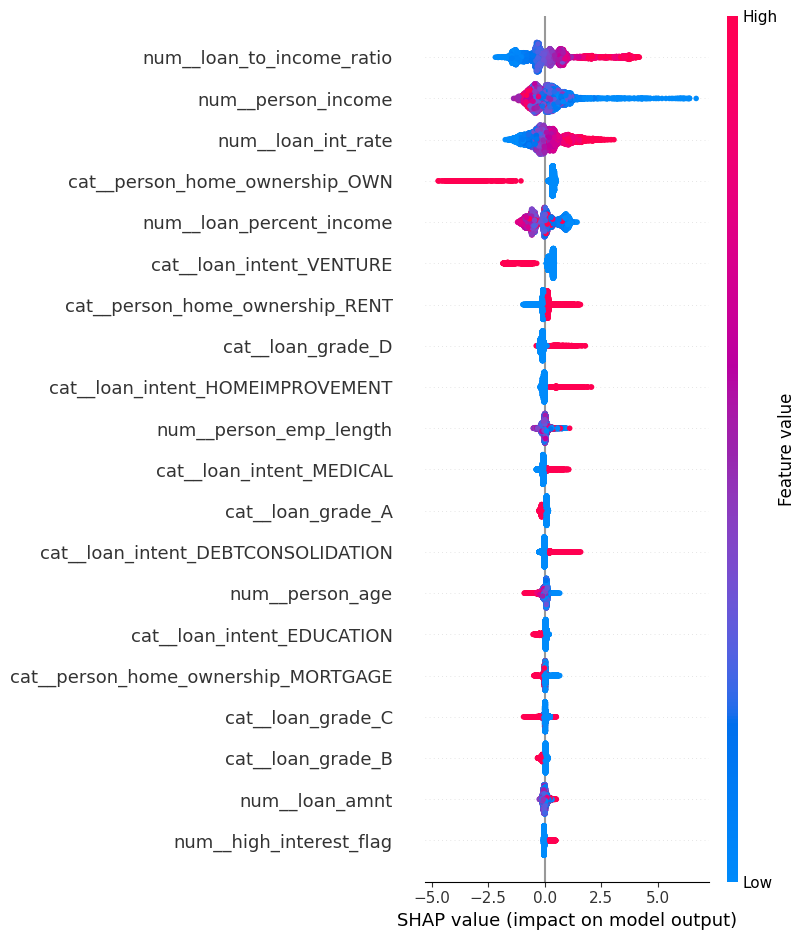

In [26]:
import shap

preprocessor = best_model.named_steps["preprocessor"]
model = best_model.named_steps["model"]

X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

X_test_shap = pd.DataFrame(
    X_test_transformed.toarray() if hasattr(X_test_transformed, "toarray") else X_test_transformed,
    columns=feature_names
)

explainer = shap.Explainer(model, X_test_shap)

shap_values = explainer(X_test_shap)

shap.summary_plot(shap_values, X_test_shap)

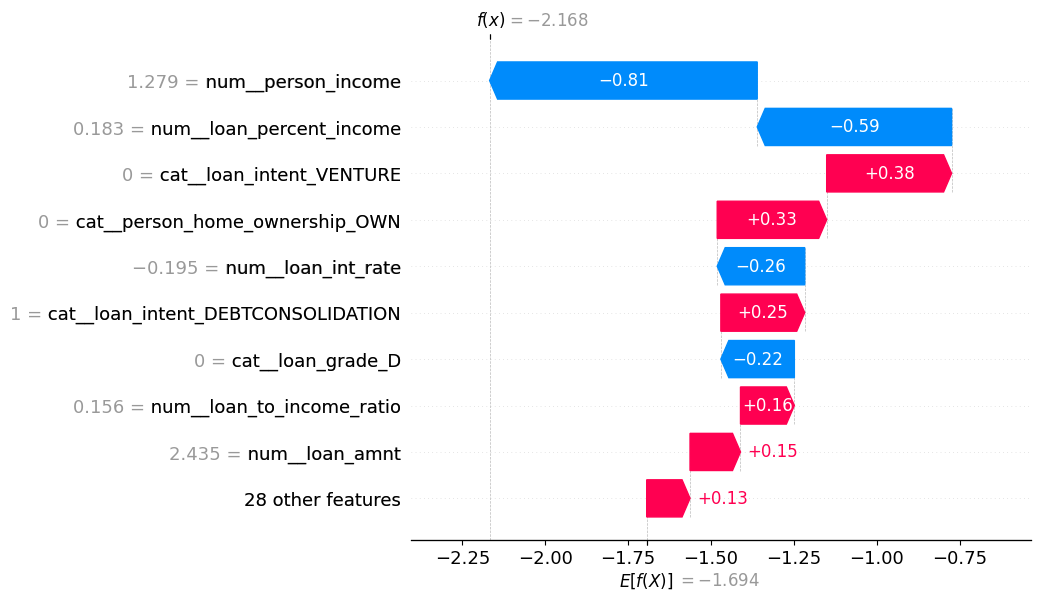

In [27]:
shap.plots.waterfall(shap_values[0])